<a href="https://colab.research.google.com/github/AdrianaVallejo97/AdrianaVallejo97/blob/main/DEA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

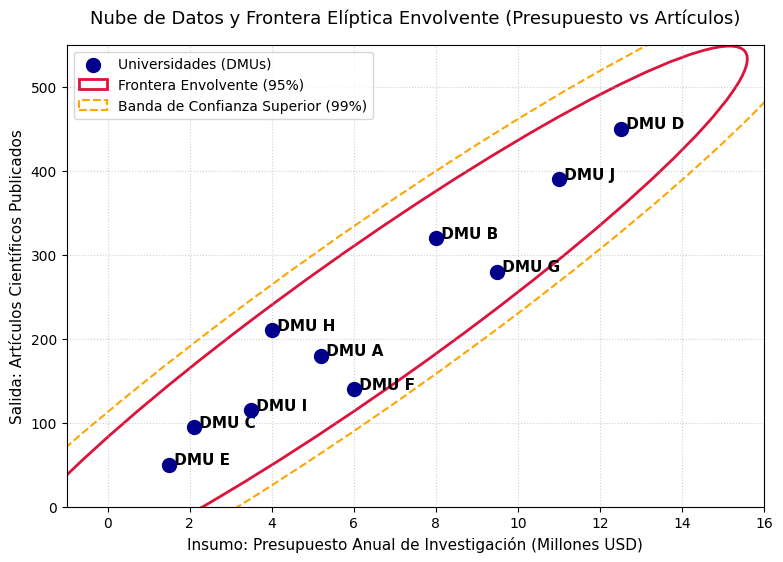

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# 1. Datos de las DMU (X2: Presupuesto, Y2: Artículos)
dmus = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
X2 = np.array([5.2, 8.0, 2.1, 12.5, 1.5, 6.0, 9.5, 4.0, 3.5, 11.0])
Y2 = np.array([180, 320, 95, 450, 50, 140, 280, 210, 115, 390])

# 2. Calcular parámetros para la elipse envolvente (Matriz de covarianza)
data = np.vstack((X2, Y2))
mu = np.mean(data, axis=1)
cov = np.cov(data)
lambda_, v = np.linalg.eig(cov)
lambda_ = np.sqrt(lambda_)

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X2, Y2, color='darkblue', s=100, zorder=5, label='Universidades (DMUs)')

# Etiquetar cada DMU
for i, txt in enumerate(dmus):
    ax.annotate(f" DMU {txt}", (X2[i], Y2[i]), fontsize=11, weight='bold')

# 3. Dibujar la Elipse Envolvente Principal (95% de confianza)
abs_v = np.abs(v)
angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))

# Frontera Envolvente Externa (Multiplicador de escala 2.448 para 95% de datos bidimensionales)
ellipse_main = Ellipse(xy=mu, width=lambda_[0]*2*2.448, height=lambda_[1]*2*2.448,
                       angle=angle, edgecolor='crimson', fc='none', lw=2,
                       linestyle='-', label='Frontera Envolvente (95%)')
ax.add_patch(ellipse_main)

# 4. Reto adicional: Banda de confianza de la envolvente (99% de confianza externa)
ellipse_band = Ellipse(xy=mu, width=lambda_[0]*2*3.035, height=lambda_[1]*2*3.035,
                       angle=angle, edgecolor='orange', fc='none', lw=1.5,
                       linestyle='--', label='Banda de Confianza Superior (99%)')
ax.add_patch(ellipse_band)

# Personalización estética
ax.set_title('Nube de Datos y Frontera Elíptica Envolvente (Presupuesto vs Artículos)', fontsize=13, pad=15)
ax.set_xlabel('Insumo: Presupuesto Anual de Investigación (Millones USD)', fontsize=11)
ax.set_ylabel('Salida: Artículos Científicos Publicados', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.xlim(-1, 16)
plt.ylim(0, 550)
plt.show()